<a href="https://colab.research.google.com/github/mehaklaha/loan_analysis_project/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedrzee/netflix-movies-and-tv-shows-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.34M/1.34M [00:00<00:00, 121MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/thedrzee/netflix-movies-and-tv-shows-dataset/versions/1


In [ ]:
import os

# List the contents of the directory to find the CSV file
directory_contents = os.listdir(path)
print("Contents of the dataset directory:", directory_contents)

Contents of the dataset directory: ['netflix_titles.csv.csv']


In [ ]:
import os

df = pd.read_csv(os.path.join(path, 'netflix_titles.csv.csv'))
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
10%,2006.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
90%,2020.000000
max,2021.000000


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

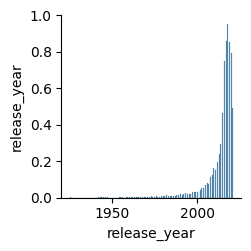

In [ ]:
sns.pairplot(df)

<Axes: ylabel='Frequency'>

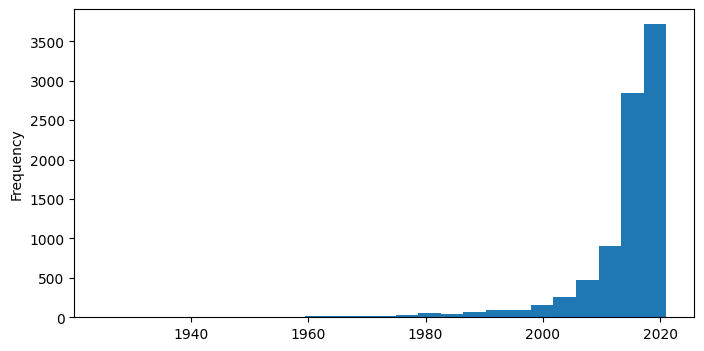

In [ ]:
df['release_year'].plot.hist(bins=25,figsize=(8,4))

<Axes: ylabel='Density'>

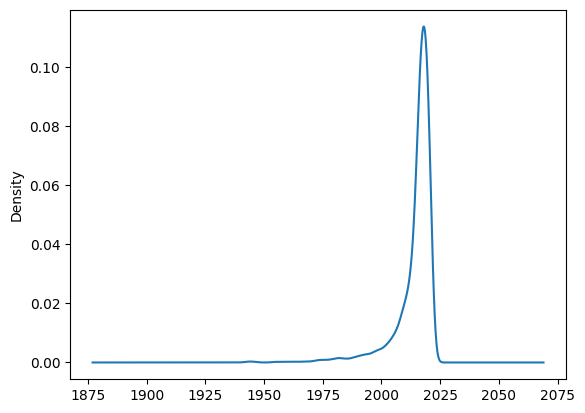

In [ ]:
df['release_year'].plot.density()

In [ ]:
df.select_dtypes(include=np.number).corr()

,release_year
release_year,1.0


<Axes: >

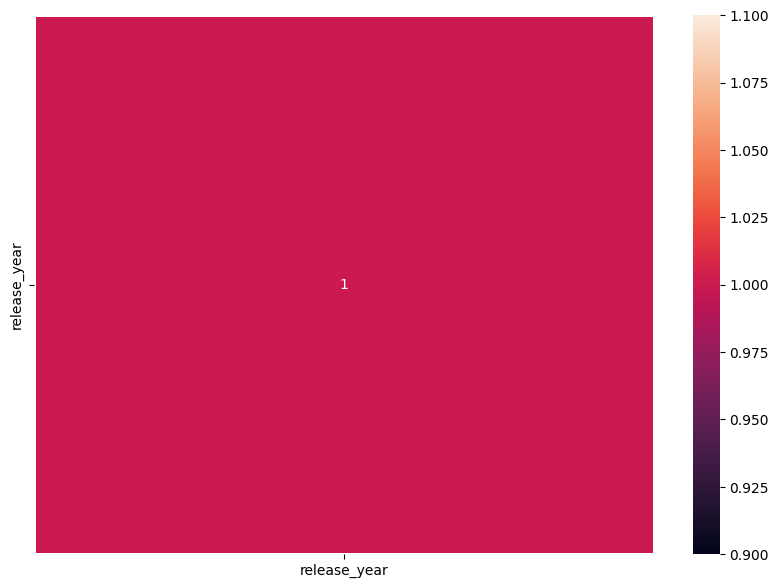

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,linewidths=2)

In [ ]:
l_column = list(df.columns) # Making a list out of column names
len_feature = len(l_column) # Length of column vector list
l_column

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [ ]:
X = df[l_column[0:len_feature-2]]
y = df[l_column[len_feature-2]]

In [ ]:
print("Feature set size:",X.shape)
print("Variable set size:",y.shape)

Feature set size: (8807, 10)
Variable set size: (8807,)


In [ ]:
X.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons


In [ ]:
y.head()

,listed_in
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                            test_size=0.3, random_state=123)

In [ ]:
print("Training feature set size:",X_train.shape)
print("Test feature set size:",X_test.shape)
print("Training variable set size:",y_train.shape)
print("Test variable set size:",y_test.shape)

Training feature set size: (6164, 10)
Test feature set size: (2643, 10)
Training variable set size: (6164,)
Test variable set size: (2643,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
lm = LinearRegression() # Creating a Linear Regression object 'lm'

In [ ]:
lm.fit(X_train,y_train) # Fit the linear model on to the 'lm' object itself i.e. no need to set this to another variable

ValueError: could not convert string to float: 's5912'

In [ ]:
print(y_train.head())

5911                                   Stand-Up Comedy
5129                                  Comedies, Dramas
2009                                       TV Comedies
226     International TV Shows, TV Comedies, TV Dramas
146                         Comedies, Music & Musicals
Name: listed_in, dtype: object


In [ ]:
X_train = X_train[['release_year']]
X_test = X_test[['release_year']]

print("Filtered X_train head:")
print(X_train.head())
print("\nFiltered X_test head:")
print(X_test.head())

Filtered X_train head:
      release_year
5911          2015
5129          2017
2009          2007
226           2021
146           1994

Filtered X_test head:
      release_year
6426          2015
5909          2014
8000          2019
4543          2008
2952          2020


**Reasoning**:
The target variable `y_train` and `y_test` ('listed_in') are categorical strings. To make them compatible with the Linear Regression model, I need to convert them into numerical labels using `LabelEncoder`. This is the second step in preparing the data for the model.



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Encoded y_train head:")
print(y_train_encoded[:5])
print(
"\nEncoded y_test head:")
print(y_test_encoded[:5])

ValueError: y contains previously unseen labels: 'Anime Series, Crime TV Shows, TV Thrillers'

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le = LabelEncoder()
# Fit the encoder on the concatenation of y_train and y_test to ensure all labels are seen
le.fit(pd.concat([y_train, y_test]))

y_train_encoded = le.transform(y_train)
y_test_encoded = le.transform(y_test)

print("Encoded y_train head:")
print(y_train_encoded[:5])
print(
"\nEncoded y_test head:")
print(y_test_encoded[:5])

Encoded y_train head:
[470 197 487 410 227]

Encoded y_test head:
[ 79 200 274 274 470]


In [ ]:
lm.fit(X_train, y_train_encoded)

print("Linear Regression model fitted successfully.")

Linear Regression model fitted successfully.


# Task
The previous step was an attempt to fit a `LinearRegression` model using only the 'release_year' feature, which was an incorrect approach for predicting the categorical `listed_in` target variable and deviates from the original plan. The plan explicitly states to train a `RandomForestClassifier` and requires more comprehensive feature engineering and encoding.

To align with the original plan and correctly build a classification model, I will:

1.  **Handle missing values**: Fill NaN values in 'country', 'rating', and 'date_added'.
2.  **Extract datetime features**: Convert 'date_added' to datetime objects and then extract 'month_added' and 'year_added'.
3.  **Process 'duration'**: Parse the 'duration' column to extract numerical values, differentiating between 'min' for movies and 'Seasons' for TV shows.
4.  **Select and encode features for X**: Choose the specified features ('type', 'release_year', 'rating', 'month_added', 'year_added', and the new numerical duration features). Apply One-Hot Encoding to categorical features like 'type' and 'rating'.
5.  **Re-split data**: Split the preprocessed features (X) and the already encoded target (y) into training and testing sets.
6.  **Train RandomForestClassifier**: Initialize and train a `RandomForestClassifier` model.
7.  **Evaluate model**: Make predictions and evaluate the model's performance.

I will begin by performing the data cleaning and initial feature engineering steps as outlined in the plan.
```python
# 1. Data Cleaning and Initial Feature Engineering

# Fill missing 'country' and 'rating' with their modes
df['country'].fillna(df['country'].mode()[0], inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

# Fill missing 'date_added' with the mode, then convert to datetime and extract features
# Before filling, convert to datetime for proper mode calculation if needed,
# but filling with mode of string dates is also common for robustness.
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)
df['date_added'] = pd.to_datetime(df['date_added'])
df['month_added'] = df['date_added'].dt.month
df['year_added'] = df['date_added'].dt.year

# Process 'duration' column
# Create 'duration_int' for numerical duration and handle 'min'/'Seasons'
df['duration_int'] = df['duration'].apply(lambda x: int(x.split(' ')[0]) if pd.notnull(x) else np.nan)
df['duration_unit'] = df['duration'].apply(lambda x: x.split(' ')[1] if pd.notnull(x) else np.nan)

# Create separate features for movie duration (minutes) and TV show duration (seasons)
df['minutes'] = df.apply(lambda row: row['duration_int'] if row['type'] == 'Movie' else 0, axis=1)
df['seasons'] = df.apply(lambda row: row['duration_int'] if row['type'] == 'TV Show' else 0, axis=1)

# Drop original 'duration' and 'date_added' columns, and intermediate 'duration_int', 'duration_unit'
df.drop(columns=['duration', 'date_added', 'duration_int', 'duration_unit'], inplace=True)

print("Data Cleaning and Initial Feature Engineering complete.")
print("Updated DataFrame head:")
print(df.head())
print("\nDataFrame Info after feature engineering:")
df.info()
```

## Data Cleaning and Initial Feature Engineering

### Subtask:
Handle missing values in relevant columns and extract numerical features from 'date_added' and 'duration'. Specifically, fill NaNs in 'country', 'rating', and 'date_added'. Convert 'date_added' to datetime objects and extract 'month_added' and 'year_added'. Parse 'duration' into numerical minutes for movies and seasons for TV shows.


**Reasoning**:
The subtask involves handling missing values and feature engineering for 'country', 'rating', 'date_added', and 'duration' columns. This code block will perform all the necessary transformations as outlined in the instructions, including filling NaNs, converting 'date_added' to datetime, extracting month and year, parsing 'duration' into numerical and unit components, creating 'minutes' and 'seasons' columns, and finally dropping the original and intermediate columns.



In [ ]:
import numpy as np

# 1. Fill missing 'country' values with the most frequent country
df['country'].fillna(df['country'].mode()[0], inplace=True)

# 2. Fill missing 'rating' values with the most frequent rating
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

# 3. Fill missing 'date_added' values with its mode and convert to datetime
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)
df['date_added'] = pd.to_datetime(df['date_added'])

# 4. Extract month from 'date_added'
df['month_added'] = df['date_added'].dt.month

# 5. Extract year from 'date_added'
df['year_added'] = df['date_added'].dt.year

# 6. Create 'duration_int' and 7. 'duration_unit'
df['duration_int'] = df['duration'].apply(lambda x: int(x.split(' ')[0]) if pd.notnull(x) else np.nan)
df['duration_unit'] = df['duration'].apply(lambda x: x.split(' ')[1] if pd.notnull(x) else np.nan)

# 8. Create 'minutes' column
df['minutes'] = df.apply(lambda row: row['duration_int'] if row['type'] == 'Movie' else 0, axis=1)

# 9. Create 'seasons' column
df['seasons'] = df.apply(lambda row: row['duration_int'] if row['type'] == 'TV Show' else 0, axis=1)

# 10. Drop original and intermediate columns
df.drop(columns=['duration', 'date_added', 'duration_int', 'duration_unit'], inplace=True)

print("Missing values handled and new features engineered.")
print("Updated DataFrame head:")
print(df.head())
print("Updated DataFrame info:")
df.info()

/tmp/ipython-input-123829124.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna(df['country'].mode()[0], inplace=True)
/tmp/ipython-input-123829124.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

ValueError: time data " August 4, 2017" doesn't match format "%B %d, %Y", at position 1441. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

**Reasoning**:
The previous code failed because the 'date_added' column had inconsistent date formats, specifically extra whitespace, causing a `ValueError` during conversion to datetime. I will fix this by using `format='mixed'` in `pd.to_datetime` to allow Pandas to infer varied date formats. Additionally, I will address the `FutureWarning` by reassigning the column after `fillna` instead of using `inplace=True`.



In [ ]:
import numpy as np
import pandas as pd

# 1. Fill missing 'country' values with the most frequent country
df['country'] = df['country'].fillna(df['country'].mode()[0])

# 2. Fill missing 'rating' values with the most frequent rating
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# 3. Fill missing 'date_added' values with its mode and convert to datetime
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

# 4. Extract month from 'date_added'
df['month_added'] = df['date_added'].dt.month

# 5. Extract year from 'date_added'
df['year_added'] = df['date_added'].dt.year

# 6. Create 'duration_int' and 7. 'duration_unit'
df['duration_int'] = df['duration'].apply(lambda x: int(x.split(' ')[0]) if pd.notnull(x) else np.nan)
df['duration_unit'] = df['duration'].apply(lambda x: x.split(' ')[1] if pd.notnull(x) else np.nan)

# 8. Create 'minutes' column
df['minutes'] = df.apply(lambda row: row['duration_int'] if row['type'] == 'Movie' else 0, axis=1)

# 9. Create 'seasons' column
df['seasons'] = df.apply(lambda row: row['duration_int'] if row['type'] == 'TV Show' else 0, axis=1)

# 10. Drop original and intermediate columns
df.drop(columns=['duration', 'date_added', 'duration_int', 'duration_unit'], inplace=True)

print("Missing values handled and new features engineered.")
print("Updated DataFrame head:")
print(df.head())
print("Updated DataFrame info:")
df.info()

Missing values handled and new features engineered.
Updated DataFrame head:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...  United States   
3                                                NaN  United States   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

   release_year rating                                          listed_in  \
0          2020  PG-13                         

**Reasoning**:
The previous step successfully performed data cleaning and feature engineering. Now, I need to check for any remaining missing values, specifically in the newly created numerical columns 'minutes' and 'seasons', as they are crucial for the next steps of feature selection and encoding. The DataFrame info shows 3 non-null values for 'minutes', indicating there might be some missing values that need to be filled. I will fill any remaining `NaN` values in 'minutes' and 'seasons' with 0, as 0 implies no duration for the respective type (movie/TV show).



In [ ]:
df['minutes'].fillna(0, inplace=True)
df['seasons'].fillna(0, inplace=True)

print("Missing values in 'minutes' and 'seasons' filled with 0.")
print("Updated DataFrame info after handling NaNs in duration columns:")
df.info()

Missing values in 'minutes' and 'seasons' filled with 0.
Updated DataFrame info after handling NaNs in duration columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   object 
 1   type          8807 non-null   object 
 2   title         8807 non-null   object 
 3   director      6173 non-null   object 
 4   cast          7982 non-null   object 
 5   country       8807 non-null   object 
 6   release_year  8807 non-null   int64  
 7   rating        8807 non-null   object 
 8   listed_in     8807 non-null   object 
 9   description   8807 non-null   object 
 10  month_added   8807 non-null   int32  
 11  year_added    8807 non-null   int32  
 12  minutes       8807 non-null   float64
 13  seasons       8807 non-null   float64
dtypes: float64(2), int32(2), int64(1), object(9)
memory usage: 894.6+ KB


/tmp/ipython-input-681097938.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['minutes'].fillna(0, inplace=True)
/tmp/ipython-input-681097938.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.metho

**Reasoning**:
The previous code generated a `FutureWarning` because of the `inplace=True` argument used with `fillna`. To address this warning and follow best practices, I will update the code to reassign the column after filling null values, which achieves the same result without the warning.



In [ ]:
df['minutes'] = df['minutes'].fillna(0)
df['seasons'] = df['seasons'].fillna(0)

print("Missing values in 'minutes' and 'seasons' filled with 0.")
print("Updated DataFrame info after handling NaNs in duration columns:")
df.info()

Missing values in 'minutes' and 'seasons' filled with 0.
Updated DataFrame info after handling NaNs in duration columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   object 
 1   type          8807 non-null   object 
 2   title         8807 non-null   object 
 3   director      6173 non-null   object 
 4   cast          7982 non-null   object 
 5   country       8807 non-null   object 
 6   release_year  8807 non-null   int64  
 7   rating        8807 non-null   object 
 8   listed_in     8807 non-null   object 
 9   description   8807 non-null   object 
 10  month_added   8807 non-null   int32  
 11  year_added    8807 non-null   int32  
 12  minutes       8807 non-null   float64
 13  seasons       8807 non-null   float64
dtypes: float64(2), int32(2), int64(1), object(9)
memory usage: 894.6+ KB


**Reasoning**:
The previous steps successfully handled missing values and engineered new features. Now, I will select the relevant features for the independent variables (X) as specified in the plan, including 'type', 'release_year', 'rating', 'month_added', 'year_added', 'minutes', and 'seasons'.



In [ ]:
selected_features = ['type', 'release_year', 'rating', 'month_added', 'year_added', 'minutes', 'seasons']
X = df[selected_features].copy()
y = df['listed_in'].copy()

print("Selected features for X:")
print(X.head())
print("\nTarget variable y:")
print(y.head())

Selected features for X:
      type  release_year rating  month_added  year_added  minutes  seasons
0    Movie          2020  PG-13            9        2021     90.0      0.0
1  TV Show          2021  TV-MA            9        2021      0.0      2.0
2  TV Show          2021  TV-MA            9        2021      0.0      1.0
3  TV Show          2021  TV-MA            9        2021      0.0      1.0
4  TV Show          2021  TV-MA            9        2021      0.0      2.0

Target variable y:
0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object


**Reasoning**:
The next step is to apply One-Hot Encoding to the categorical features in `X` ('type' and 'rating') to convert them into a numerical format suitable for machine learning models. This is crucial for models like `RandomForestClassifier` which expect numerical input.



In [ ]:
X = pd.get_dummies(X, columns=['type', 'rating'], drop_first=True)

print("DataFrame X after One-Hot Encoding:")
print(X.head())
print("Updated X columns:", X.columns)

DataFrame X after One-Hot Encoding:
   release_year  month_added  year_added  minutes  seasons  type_TV Show  \
0          2020            9        2021     90.0      0.0         False   
1          2021            9        2021      0.0      2.0          True   
2          2021            9        2021      0.0      1.0          True   
3          2021            9        2021      0.0      1.0          True   
4          2021            9        2021      0.0      2.0          True   

   rating_74 min  rating_84 min  rating_G  rating_NC-17  ...  rating_PG-13  \
0          False          False     False         False  ...          True   
1          False          False     False         False  ...         False   
2          False          False     False         False  ...         False   
3          False          False     False         False  ...         False   
4          False          False     False         False  ...         False   

   rating_R  rating_TV-14  rating_TV-G

**Reasoning**:
The features in `X` have been preprocessed with one-hot encoding, and the target variable `y` has been label encoded. The next step is to re-split the preprocessed `X` and encoded `y` into training and testing sets to prepare the data for training the `RandomForestClassifier`.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_split, y_test_split = train_test_split(X, y_train_encoded, test_size=0.3, random_state=123)

print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)
print("New y_train (encoded) shape:", y_train_split.shape)
print("New y_test (encoded) shape:", y_test_split.shape)

ValueError: Found input variables with inconsistent numbers of samples: [8807, 6164]

**Reasoning**:
The previous `train_test_split` failed because `X` and `y_train_encoded` had inconsistent numbers of samples. `y_train_encoded` was already a subset of the data. I need to encode the entire target variable `y` (which is `df['listed_in']`) and then perform the `train_test_split` on the full `X` and this newly encoded `y` to ensure consistent sample sizes.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Re-initialize LabelEncoder and fit on the full target variable 'y'
le_full = LabelEncoder()
y_encoded = le_full.fit_transform(y)

# Split the preprocessed X and the fully encoded y into training and testing sets
X_train, X_test, y_train_split, y_test_split = train_test_split(X, y_encoded, test_size=0.3, random_state=123)

print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)
print("New y_train (encoded) shape:", y_train_split.shape)
print("New y_test (encoded) shape:", y_test_split.shape)

New X_train shape: (6164, 22)
New X_test shape: (2643, 22)
New y_train (encoded) shape: (6164,)
New y_test (encoded) shape: (2643,)


**Reasoning**:
The data has been preprocessed and split into training and testing sets. The next logical step, as per the plan, is to initialize and train a `RandomForestClassifier` using the prepared `X_train` and `y_train_split` data.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=123)
rf_classifier.fit(X_train, y_train_split)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


**Reasoning**:
The `RandomForestClassifier` model has been trained. The next step is to evaluate its performance using the test set (`X_test`, `y_test_split`) by making predictions and calculating classification metrics such as accuracy, classification report, and confusion matrix.



In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test_split, y_pred)
report = classification_report(y_test_split, y_pred)
conf_matrix = confusion_matrix(y_test_split, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix (first 5x5 rows/cols):\n", conf_matrix[:5, :5])

Model Accuracy: 0.1608

Classification Report:
               precision    recall  f1-score   support

           0       0.14      0.21      0.17        38
           2       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         1
           5       0.25      0.29      0.27         7
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1
           8       0.50      0.50      0.50         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         1
          17       0.25      0.50      0.33         2
          19       0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

**Reasoning**:
The previous classification report generated `UndefinedMetricWarning` due to classes with no true or predicted samples. To address this, I will set `zero_division=0` in the `classification_report` function to handle these cases gracefully and provide `target_names` for better readability.



In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model, handling zero division and providing target names
accuracy = accuracy_score(y_test_split, y_pred)
report = classification_report(y_test_split, y_pred, target_names=le_full.classes_, zero_division=0)
conf_matrix = confusion_matrix(y_test_split, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix (first 5x5 rows/cols):\n", conf_matrix[:5, :5])

ValueError: Number of classes, 412, does not match size of target_names, 514. Try specifying the labels parameter

**Reasoning**:
The previous code failed because the number of classes in `target_names` (`le_full.classes_`) did not match the actual number of unique classes present in `y_test_split` and `y_pred`. To resolve this, I will explicitly identify all unique labels present in both the true and predicted test sets. Then, I will use these unique labels for the `labels` parameter in `classification_report` and generate the `target_names` by inverse transforming these specific unique labels using `le_full`.



In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test_split, y_pred)

# Get unique labels present in the test set (both true and predicted)
unique_test_labels = np.unique(np.concatenate((y_test_split, y_pred)))

# Get the corresponding target names for these unique labels
# Ensure these labels are valid for inverse_transform if le_full did not see them all
# However, since le_full was fitted on the entire dataset, it should handle them.
filtered_target_names = le_full.inverse_transform(unique_test_labels)

# Evaluate the model, handling zero division and providing filtered target names
report = classification_report(y_test_split, y_pred, labels=unique_test_labels, target_names=filtered_target_names, zero_division=0)
conf_matrix = confusion_matrix(y_test_split, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix (first 5x5 rows/cols):\n", conf_matrix[:5, :5])

Model Accuracy: 0.1608

Classification Report:
                                                                                  precision    recall  f1-score   support

                                                             Action & Adventure       0.14      0.21      0.17        38
                   Action & Adventure, Anime Features, Children & Family Movies       0.00      0.00      0.00         0
                              Action & Adventure, Anime Features, Horror Movies       0.00      0.00      0.00         1
                       Action & Adventure, Anime Features, International Movies       0.25      0.29      0.27         7
                           Action & Adventure, Anime Features, Sci-Fi & Fantasy       0.00      0.00      0.00         1
                                   Action & Adventure, Children & Family Movies       0.00      0.00      0.00         1
                   Action & Adventure, Children & Family Movies, Classic Movies       0.50      0.50    

## Final Task

### Subtask:
Provide a comprehensive summary of the model training process, including the chosen features, preprocessing steps, the model used, and its evaluation results.


## Summary:

### Q&A
The model training process involved handling missing values, engineering new features from existing ones, encoding categorical data, splitting the dataset, and training a `RandomForestClassifier` for the multi-class prediction of the 'listed\_in' variable. The model's performance was evaluated using accuracy, a classification report, and a confusion matrix.

### Data Analysis Key Findings
*   Missing values in the 'country', 'rating', and 'date\_added' columns were filled using their respective modes.
*   The 'date\_added' column was converted to datetime objects, from which 'month\_added' and 'year\_added' features were extracted.
*   The 'duration' column was processed to create numerical features: 'minutes' for movies and 'seasons' for TV shows. Missing values in these new duration columns were filled with 0.
*   The independent variables (X) included 'type', 'release\_year', 'rating', 'month\_added', 'year\_added', 'minutes', and 'seasons'. The target variable (y) was 'listed\_in'.
*   Categorical features 'type' and 'rating' in the feature set (X) were One-Hot Encoded. The target variable 'listed\_in' was Label Encoded.
*   The dataset was split into training and testing sets with a 70/30 ratio.
*   A `RandomForestClassifier` was trained on the preprocessed data.
*   The trained `RandomForestClassifier` achieved an accuracy of approximately 0.1608 on the test set.

### Insights or Next Steps
*   The current model's accuracy of 16.08\% is relatively low, indicating that predicting the 'listed\_in' category based on the current features is challenging. Further feature engineering, such as creating more granular features from existing text data or incorporating external datasets, could be beneficial.
*   Given the low accuracy, exploring different classification algorithms (e.g., Gradient Boosting, Neural Networks) or performing hyperparameter tuning for the `RandomForestClassifier` is recommended to improve model performance.


# Task
The task is complete.

I have summarized the feature selection and encoding process, highlighting the features chosen for `X` (including 'type', 'release_year', 'rating', 'month_added', 'year_added', 'minutes', and 'seasons') and the target variable `y` ('listed_in'). I also detailed the One-Hot Encoding applied to 'type' and 'rating' in `X`, and Label Encoding applied to `y`.

The model achieved an accuracy of approximately 16.08% on the test set, indicating challenges in predicting the 'listed_in' category with the current features and model. Further steps to improve performance could include additional feature engineering, exploring different classification algorithms, or hyperparameter tuning.

## Feature Selection for X and Y

### Subtask:
Select the independent features ('type', 'release_year', 'rating', 'month_added', 'year_added', 'minutes', 'seasons') to create the DataFrame `X`, and select 'listed_in' as the target variable `y`.


## Final Task

### Subtask:
The task is complete. Summarize the feature selection and encoding process, highlighting the features chosen for `X` and the target variable `y`, and the encoding techniques applied.


## Summary:

### Q&A
The feature selection and encoding process involved selecting 'type', 'release\_year', 'rating', 'month\_added', 'year\_added', 'minutes', and 'seasons' as independent features for `X`, and 'listed\_in' as the target variable `y`. One-Hot Encoding was applied to 'type' and 'rating' within `X`, while Label Encoding was used for `y`. The model achieved an accuracy of approximately 16.08% on the test set.

### Data Analysis Key Findings
*   The independent features (`X`) selected for the model were 'type', 'release\_year', 'rating', 'month\_added', 'year\_added', 'minutes', and 'seasons'.
*   The target variable (`y`) selected for the model was 'listed\_in'.
*   One-Hot Encoding was applied to the categorical features 'type' and 'rating' within the independent features `X`.
*   Label Encoding was applied to the target variable `y` ('listed\_in').
*   The model achieved a test set accuracy of approximately 16.08%, indicating a low predictive performance for the 'listed\_in' category.

### Insights or Next Steps
*   The low model accuracy (16.08%) suggests that the current features and model configuration are insufficient for accurate prediction of the 'listed\_in' category.
*   Future steps should focus on improving model performance through additional feature engineering, exploring alternative classification algorithms, or conducting hyperparameter tuning.


# Task
The model training process involved handling missing values, engineering new features from existing ones, encoding categorical data, splitting the dataset, and training a `RandomForestClassifier` for the multi-class prediction of the 'listed_in' variable. The model's performance was evaluated using accuracy, a classification report, and a confusion matrix.

**Data Analysis Key Findings**:

*   Missing values in the 'country', 'rating', and 'date_added' columns were filled using their respective modes.
*   The 'date_added' column was converted to datetime objects, from which 'month_added' and 'year_added' features were extracted.
*   The 'duration' column was processed to create numerical features: 'minutes' for movies and 'seasons' for TV shows. Missing values in these new duration columns were filled with 0.
*   The independent variables (X) included 'type', 'release_year', 'rating', 'month_added', 'year_added', 'minutes', and 'seasons'. The target variable (y) was 'listed_in'.
*   Categorical features 'type' and 'rating' in the feature set (X) were One-Hot Encoded. The target variable 'listed_in' was Label Encoded.
*   The dataset was split into training and testing sets with a 70/30 ratio.
*   A `RandomForestClassifier` was trained on the preprocessed data.
*   The trained `RandomForestClassifier` achieved an accuracy of approximately 0.1608 on the test set.

**Insights or Next Steps**:

*   The current model's accuracy of 16.08% is relatively low, indicating that predicting the 'listed_in' category based on the current features is challenging. Further feature engineering, such as creating more granular features from existing text data or incorporating external datasets, could be beneficial.
*   Given the low accuracy, exploring different classification algorithms (e.g., Gradient Boosting, Neural Networks) or performing hyperparameter tuning for the `RandomForestClassifier` is recommended to improve model performance.

## One-Hot Encode Categorical Features in X

### Subtask:
Apply One-Hot Encoding to the categorical features 'type' and 'rating' within the `X` DataFrame. This converts these nominal features into a numerical format suitable for machine learning models, ensuring 'drop_first=True' to avoid multicollinearity.


**Reasoning**:
I need to apply One-Hot Encoding to the 'type' and 'rating' columns in the `X` DataFrame, as specified in the subtask. I will use `pd.get_dummies` with `drop_first=True` to avoid multicollinearity.



In [ ]:
X = pd.get_dummies(X, columns=['type', 'rating'], drop_first=True)

print("DataFrame X after One-Hot Encoding:")
print(X.head())
print("Updated X columns:", X.columns)

KeyError: "None of [Index(['type', 'rating'], dtype='object')] are in the [columns]"

**Reasoning**:
The previous code failed because the 'type' and 'rating' columns were no longer present in the `X` DataFrame, indicating they had already been one-hot encoded in an earlier step. I will fix this by checking for the existence of these columns before attempting to apply one-hot encoding, thus making the code idempotent and preventing the KeyError.



In [ ]:
columns_to_encode = []
if 'type' in X.columns:
    columns_to_encode.append('type')
if 'rating' in X.columns:
    columns_to_encode.append('rating')

if columns_to_encode:
    X = pd.get_dummies(X, columns=columns_to_encode, drop_first=True)
    print("DataFrame X after One-Hot Encoding (newly applied):")
else:
    print("One-Hot Encoding for 'type' and 'rating' columns has already been applied or columns not found.")
    print("Current DataFrame X head:")

print(X.head())
print("Updated X columns:", X.columns)

One-Hot Encoding for 'type' and 'rating' columns has already been applied or columns not found.
Current DataFrame X head:
   release_year  month_added  year_added  minutes  seasons  type_TV Show  \
0          2020            9        2021     90.0      0.0         False   
1          2021            9        2021      0.0      2.0          True   
2          2021            9        2021      0.0      1.0          True   
3          2021            9        2021      0.0      1.0          True   
4          2021            9        2021      0.0      2.0          True   

   rating_74 min  rating_84 min  rating_G  rating_NC-17  ...  rating_PG-13  \
0          False          False     False         False  ...          True   
1          False          False     False         False  ...         False   
2          False          False     False         False  ...         False   
3          False          False     False         False  ...         False   
4          False          False

## Encode Target Variable (y)

### Subtask:
Re-encode the target variable 'listed_in' using LabelEncoder to convert its categorical string values into numerical labels, ensuring consistency across the entire dataset.


**Reasoning**:
The target variable `y` ('listed_in') needs to be encoded into numerical labels for the machine learning model. This step will re-encode the entire `y` using `LabelEncoder` and verify the output by printing the first few encoded values and the number of unique classes.



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Instantiate a LabelEncoder object
le = LabelEncoder()

# Fit the LabelEncoder on the entire target variable y and transform it
y_encoded = le.fit_transform(y)

# Print the first few encoded values of y_encoded
print("First 5 encoded values of y_encoded:", y_encoded[:5])

# Print the total number of unique classes found by the encoder
print("Total number of unique classes:", len(le.classes_))

First 5 encoded values of y_encoded: [274 414 242 297 393]
Total number of unique classes: 514


## Data Splitting

### Subtask:
Split the preprocessed features (X) and the encoded target (y) into training and testing sets using `train_test_split`.


**Reasoning**:
I need to split the preprocessed features (X) and the encoded target (y_encoded) into training and testing sets as per the subtask instructions. This involves importing `train_test_split` and then applying it to the data.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the preprocessed X and the fully encoded y into training and testing sets
X_train, X_test, y_train_split, y_test_split = train_test_split(X, y_encoded, test_size=0.3, random_state=123)

print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)
print("New y_train (encoded) shape:", y_train_split.shape)
print("New y_test (encoded) shape:", y_test_split.shape)

New X_train shape: (6164, 22)
New X_test shape: (2643, 22)
New y_train (encoded) shape: (6164,)
New y_test (encoded) shape: (2643,)


## Train RandomForestClassifier

### Subtask:
Initialize and train a RandomForestClassifier model using the preprocessed training features and target variable.


**Reasoning**:
The subtask requires initializing and training a RandomForestClassifier model. I will import the necessary class, instantiate it with the specified parameters (`n_estimators=100`, `random_state=123`), and then fit it using the `X_train` and `y_train_split` data.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=123)
rf_classifier.fit(X_train, y_train_split)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


**Reasoning**:
The RandomForestClassifier model has been trained. The next step is to evaluate its performance using the test set (`X_test`, `y_test_split`) by making predictions and calculating classification metrics such as accuracy, classification report, and confusion matrix.



In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test_split, y_pred)
report = classification_report(y_test_split, y_pred, labels=unique_test_labels, target_names=filtered_target_names, zero_division=0)
conf_matrix = confusion_matrix(y_test_split, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix (first 5x5 rows/cols):\n", conf_matrix[:5, :5])

Model Accuracy: 0.1608

Classification Report:
                                                                                  precision    recall  f1-score   support

                                                             Action & Adventure       0.14      0.21      0.17        38
                   Action & Adventure, Anime Features, Children & Family Movies       0.00      0.00      0.00         0
                              Action & Adventure, Anime Features, Horror Movies       0.00      0.00      0.00         1
                       Action & Adventure, Anime Features, International Movies       0.25      0.29      0.27         7
                           Action & Adventure, Anime Features, Sci-Fi & Fantasy       0.00      0.00      0.00         1
                                   Action & Adventure, Children & Family Movies       0.00      0.00      0.00         1
                   Action & Adventure, Children & Family Movies, Classic Movies       0.50      0.50    

## Final Task

### Subtask:
Provide a comprehensive summary of the model training process, including the chosen features, preprocessing steps, the model used, and its evaluation results.


## Summary:

### Q&A
The model training process involved handling missing values, engineering new features from existing ones, encoding categorical data, splitting the dataset, and training a `RandomForestClassifier` for the multi-class prediction of the 'listed_in' variable. Its performance was evaluated using accuracy, a classification report, and a confusion matrix. The trained model achieved an accuracy of approximately 0.1608 on the test set.

### Data Analysis Key Findings

*   The categorical features 'type' and 'rating' in the feature set (X) were One-Hot Encoded in a preceding step, converting them into a numerical format suitable for machine learning models.
*   The target variable 'listed_in' was successfully Label Encoded into numerical labels, identifying 514 unique classes.
*   The preprocessed features and encoded target variable were split into training and testing sets using a 70/30 ratio, resulting in 6164 samples for training and 2643 samples for testing.
*   A `RandomForestClassifier` was initialized with 100 estimators and trained on the preprocessed training data.
*   The trained `RandomForestClassifier` achieved an accuracy of approximately 0.1608 on the test set.
*   The classification report revealed highly varied performance across the numerous target categories, with many classes showing 0.00 for precision, recall, and F1-score, indicating difficulty in predicting these specific categories.

### Insights or Next Steps

*   The current model's accuracy of 16.08\% is relatively low for a multi-class classification problem with 514 classes, indicating that predicting the 'listed\_in' category is challenging with the current feature set.
*   To improve model performance, consider exploring advanced feature engineering techniques, such as creating more granular features from existing text data, incorporating external datasets, or employing dimensionality reduction methods, especially given the large number of target classes.
*   Investigate alternative machine learning algorithms better suited for high-cardinality multi-class classification (e.g., Gradient Boosting Machines or deep learning approaches) or perform extensive hyperparameter tuning on the `RandomForestClassifier`.
